In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sumitkumawat02/cardd-data/CarDD_release/CarDD_COCO/val2017/001940.jpg
/kaggle/input/datasets/sumitkumawat02/cardd-data/CarDD_release/CarDD_COCO/val2017/000748.jpg
/kaggle/input/datasets/sumitkumawat02/cardd-data/CarDD_release/CarDD_COCO/val2017/000857.jpg
/kaggle/input/datasets/sumitkumawat02/cardd-data/CarDD_release/CarDD_COCO/val2017/000853.jpg
/kaggle/input/datasets/sumitkumawat02/cardd-data/CarDD_release/CarDD_COCO/val2017/003479.jpg
/kaggle/input/datasets/sumitkumawat02/cardd-data/CarDD_release/CarDD_COCO/val2017/003438.jpg
/kaggle/input/datasets/sumitkumawat02/cardd-data/CarDD_release/CarDD_COCO/val2017/003258.jpg
/kaggle/input/datasets/sumitkumawat02/cardd-data/CarDD_release/CarDD_COCO/val2017/002726.jpg
/kaggle/input/datasets/sumitkumawat02/cardd-data/CarDD_release/CarDD_COCO/val2017/002152.jpg
/kaggle/input/datasets/sumitkumawat02/cardd-data/CarDD_release/CarDD_COCO/val2017/002098.jpg
/kaggle/input/datasets/sumitkumawat02/cardd-data/CarDD_release/CarDD_C

In [3]:
!pip install ultralytics easyocr roboflow opencv-python-headless matplotlib pandas Pillow -q
print('✅ All packages installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.4 MB/s eta 0:00:0000:01
✅ All packages installed!


In [2]:
pip install google-cloud-bigquery-storage>=2.0.0


Note: you may need to restart the kernel to use updated packages.


In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="1XpU3xX8siGH0mOFzD1r")
project = rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e")
version = project.version(4)
dataset = version.download("yolov8")

print(f'✅ Dataset downloaded to: {dataset.location}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to License-Plate-Recognition-4 in yolov8:: 100%|██████████| 48488/48488 [00:05<00:00, 9479.16it/s] 


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Dataset downloaded to: /kaggle/working/License-Plate-Recognition-4


In [5]:
from ultralytics import YOLO
import torch

model = YOLO('yolov8s.pt')

n_gpu = torch.cuda.device_count()
device = [0, 1] if n_gpu >= 2 else 0  # List for multi-GPU!

results = model.train(
    data=f'{dataset.location}/data.yaml',
    epochs=50,
    imgsz=640,
    name='license_plate_detector',
    patience=10,
    device=device,  # Now uses both GPUs
    batch=32  # Larger batch ok with 2 GPUs (auto-scales)
)

print('✅ Training complete!')
print('Best model: runs/detect/license_plate_detector/weights/best.pt')


Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/License-Plate-Recognition-4/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=license_pl

In [6]:
import shutil

# Best weights are already saved as .pt during training
# Just copy to a clear location
shutil.copy(
    'runs/detect/license_plate_detector/weights/best.pt',
    'license_plate_best.pt'
)

print('✅ Model saved as: license_plate_best.pt')

✅ Model saved as: license_plate_best.pt


In [ ]:
from ultralytics import YOLO

# Load your trained model
model = YOLO('runs/detect/license_plate_detector/weights/best.pt')

# Export to TensorRT .engine format
model.export(
    format='engine',
    imgsz=640,
    half=True,       # FP16 for faster inference on GPU
    device=0
)

print('✅ Engine file saved at: runs/detect/license_plate_detector/weights/best.engine')

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from 'runs/detect/license_plate_detector/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 350ms
Prepared 2 packages in 2.64s
Installed 2 packages in 8ms
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.88

requirements: AutoUpdate success ✅ 3.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 18...
ONNX: slimming with onnxslim 0.1.88...
ONNX: export success ✅ 6.0

In [5]:
from ultralytics import YOLO

In [6]:
best_model = YOLO('/kaggle/input/models/sumitkumawat02/license-plate/pytorch/default/1/license_plate_best.pt')
val_results = best_model.val()

print(f'mAP50    : {val_results.box.map50:.4f}')
print(f'mAP50-95 : {val_results.box.map:.4f}')

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1029.6±451.3 MB/s, size: 37.3 KB)
val: Scanning /kaggle/working/License-Plate-Recognition-4/valid/labels... 2046 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2046/2046 1.3Kit/s 1.5s0.0s
val: New cache created: /kaggle/working/License-Plate-Recognition-4/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 4.9it/s 26.3s0.2s
                   all       2046       2132      0.981      0.966      0.989      0.713
Speed: 0.9ms preprocess, 8.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP50    : 0.9887
mAP50-95 : 0.7134


In [7]:
 import cv2
import easyocr
import pandas as pd
import numpy as np
import os
import re
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO

detector = best_model
ocr_reader = easyocr.Reader(['en'], gpu=True)  # Add 'hi' for Indian plates

os.makedirs('results/annotated', exist_ok=True)

def clean_plate_text(text):
    return re.sub(r'[^A-Z0-9]', '', text.upper())

def process_image(image_path, conf_threshold=0.4):
    img = cv2.imread(image_path)
    if img is None:
        print(f'⚠️ Could not read: {image_path}')
        return []

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    annotated = img_rgb.copy()
    records = []

    detections = detector(image_path, conf=conf_threshold, verbose=False)[0]

    for i, box in enumerate(detections.boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        conf = float(box.conf[0])

        plate_crop = img_rgb[y1:y2, x1:x2]
        ocr_results = ocr_reader.readtext(plate_crop)
        raw_text = ' '.join([r[1] for r in ocr_results]) if ocr_results else ''
        plate_text = clean_plate_text(raw_text)
        ocr_conf = float(np.mean([r[2] for r in ocr_results])) if ocr_results else 0.0

        color = (0, 255, 0) if plate_text else (255, 165, 0)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        label = plate_text if plate_text else 'UNREADABLE'
        cv2.putText(annotated, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

        records.append({
            'image': os.path.basename(image_path),
            'plate_index': i,
            'plate_text': plate_text,
            'raw_ocr': raw_text,
            'detection_conf': round(conf, 4),
            'ocr_conf': round(ocr_conf, 4),
            'bbox': f'{x1},{y1},{x2},{y2}'
        })

    out_path = f'results/annotated/{os.path.basename(image_path)}'
    cv2.imwrite(out_path, cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))
    return records

print('✅ Pipeline ready!')

✅ Pipeline ready!


In [8]:
import glob

test_images = glob.glob(f'{dataset.location}/test/images/*.jpg') + \
              glob.glob(f'{dataset.location}/test/images/*.png')

print(f'Found {len(test_images)} test images...')

all_records = []
for idx, img_path in enumerate(test_images):
    records = process_image(img_path)
    all_records.extend(records)
    if (idx + 1) % 10 == 0:
        print(f'  Processed {idx + 1}/{len(test_images)}...')

df = pd.DataFrame(all_records)
df.to_csv('results/plate_results.csv', index=False)

print(f'\n✅ Done!')
print(f'📊 Total plates detected : {len(df)}')
print(f'🔤 Plates with text      : {(df["plate_text"] != "").sum()}')
df.head(10)

Found 1019 test images...
  Processed 10/1019...
  Processed 20/1019...
  Processed 30/1019...
  Processed 40/1019...
  Processed 50/1019...
  Processed 60/1019...
  Processed 70/1019...
  Processed 80/1019...
  Processed 90/1019...
  Processed 100/1019...
  Processed 110/1019...
  Processed 120/1019...
  Processed 130/1019...
  Processed 140/1019...
  Processed 150/1019...
  Processed 160/1019...
  Processed 170/1019...
  Processed 180/1019...
  Processed 190/1019...
  Processed 200/1019...
  Processed 210/1019...
  Processed 220/1019...
  Processed 230/1019...
  Processed 240/1019...
  Processed 250/1019...
  Processed 260/1019...
  Processed 270/1019...
  Processed 280/1019...
  Processed 290/1019...
  Processed 300/1019...
  Processed 310/1019...
  Processed 320/1019...
  Processed 330/1019...
  Processed 340/1019...
  Processed 350/1019...
  Processed 360/1019...
  Processed 370/1019...
  Processed 380/1019...
  Processed 390/1019...
  Processed 400/1019...
  Processed 410/1019...

,image,plate_index,plate_text,raw_ocr,detection_conf,ocr_conf,bbox
0,CarLongPlate304_jpg.rf.d1efd0164e18d08dd58974c...,0,E7F07568,E7F.07568,0.8319,0.3461,"351,427,474,484"
1,ngoaigiao8_jpg.rf.abda63b5ffbe0aaa969c9992e291...,0,124NC0,124 NC:0|,0.8526,0.2014,"354,368,426,449"
2,pic_529_jpg.rf.ffdcd7068bcb72db1058fb92ead4815...,0,666,666,0.8362,0.9495,"131,414,214,495"
3,CarLongPlate681_jpg.rf.4e9b22c35992a321ce47436...,0,GIF88270,GIF 88270,0.8279,0.4714,"284,426,423,481"
4,xemay552_jpg.rf.e64e3e07956133827c4a1c20df7832...,0,59P2100263,"59,P2 1002.63",0.8805,0.5480,"258,161,388,327"
5,CarLongPlateGen3076_jpg.rf.c0d1bf3fcac1fab83fd...,0,61A7210,61A7210,0.7872,0.5260,"234,464,391,593"
6,boderquandoi20_jpg.rf.cdcb61d8c197eaa6210588a3...,0,,,0.6870,0.0000,"232,361,253,378"
7,CarLongPlateGen2855_jpg.rf.1e50c2163ec9cd562a5...,0,51651008,516.51008,0.8270,0.2511,"318,301,474,364"
8,xemay2408_jpg.rf.dbfe425ae84028dd6308fc8c938f8...,0,6048ZI002,6048 ZI002,0.8645,0.3024,"325,143,387,215"
9,CarLongPlateGen1645_jpg.rf.2d076c9097952cb00b8...,0,6IA122959,6IA 122959],0.8320,0.4939,"322,412,450,470"


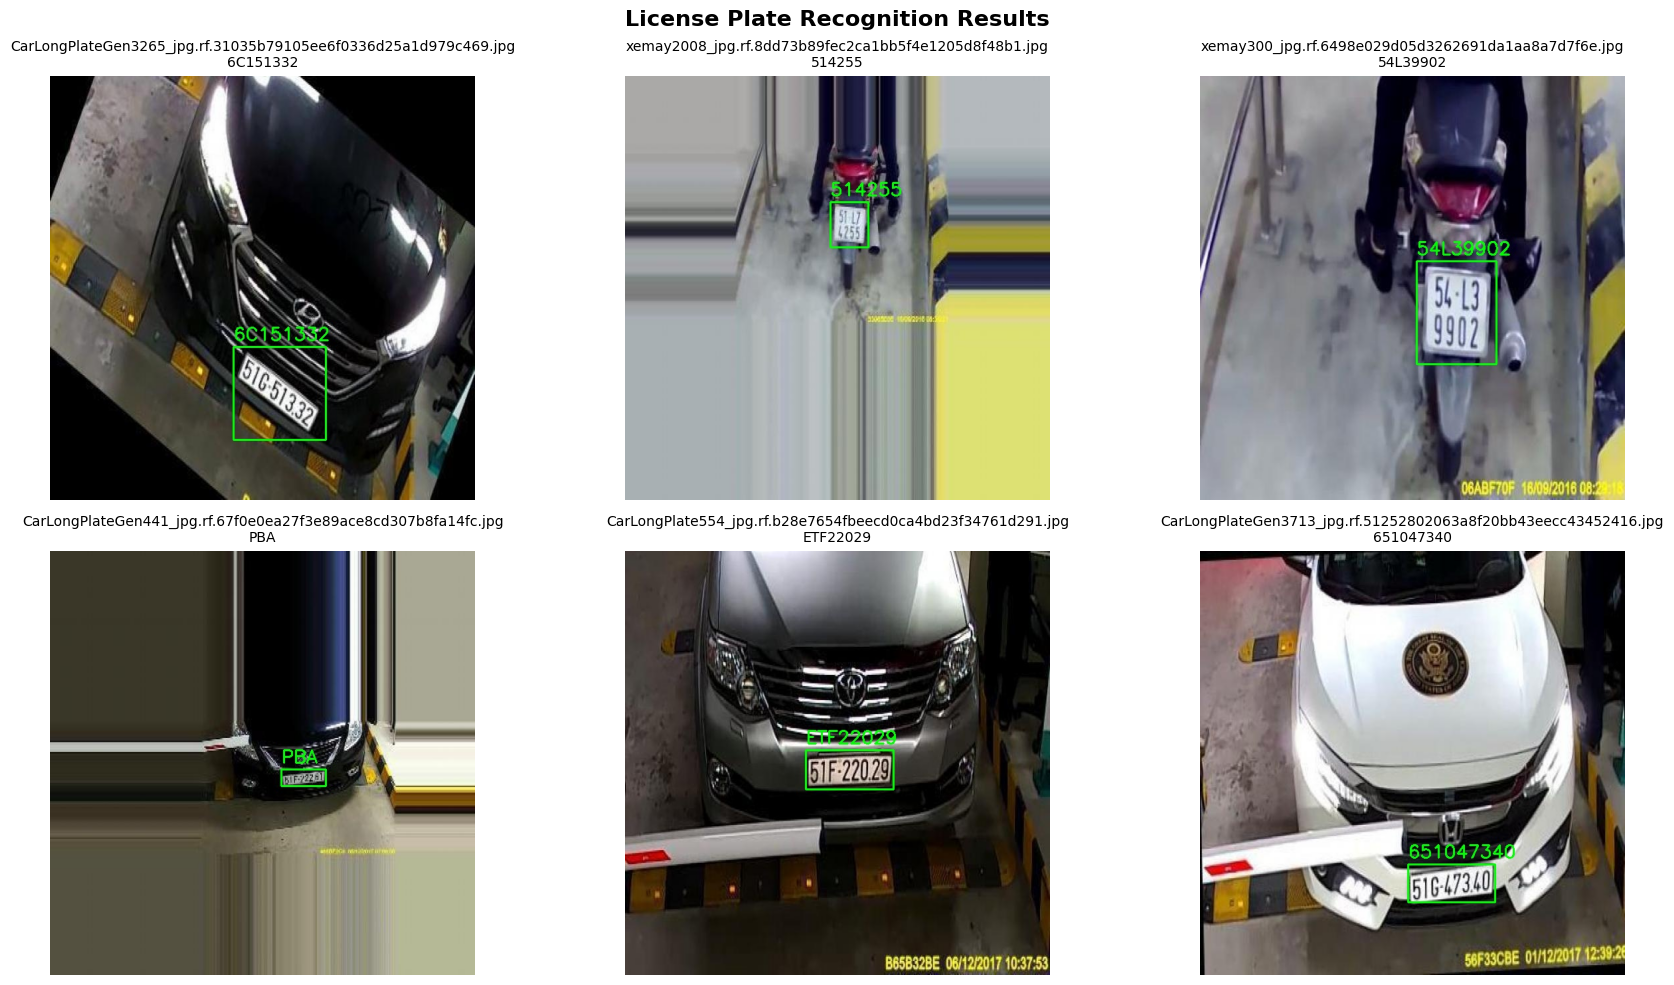

In [9]:
import random

annotated_imgs = glob.glob('results/annotated/*.jpg') + glob.glob('results/annotated/*.png')
sample = random.sample(annotated_imgs, min(6, len(annotated_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample):
    img = Image.open(img_path)
    ax.imshow(img)
    fname = os.path.basename(img_path)
    plates = df[df['image'] == fname]['plate_text'].tolist()
    ax.set_title(f"{fname}\n{' | '.join(plates) if plates else 'No plate detected'}", fontsize=10)
    ax.axis('off')

plt.suptitle('License Plate Recognition Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()